# Pemantauan Polusi Udara

## Pendahuluan
Pada notebook ini, kita akan membangun model prediksi untuk memantau tingkat polusi udara di suatu wilayah menggunakan metode **K-Nearest Neighbors (KNN)**. Model ini bertujuan untuk memprediksi status polusi udara berdasarkan data historis dan kondisi lingkungan seperti cuaca, aktivitas industri, dan tingkat transportasi.

## Import Library yang Dibutuhkan
Kita akan menggunakan beberapa library Python untuk melakukan analisis dan membangun model prediksi.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

## Langkah 1: Memuat Dataset
Kita akan memuat dataset yang telah dibuat sebelumnya mengenai kondisi polusi udara.

In [2]:
# Load the dataset
dummy_polusi_df = pd.read_excel('5_pemantauan_polusi_udara.xlsx')
dummy_polusi_df

,Date,Location,Temperature (C),Humidity (%),Vehicle Count,Industrial Activity Level,Weather Event,Pollution Status
0,2025-01-22,Suburb,20.452329,58,540,6,Fog,0
1,2025-02-16,Suburb,33.349968,50,721,3,Fog,0
2,2025-01-01,Industrial Zone,37.363117,78,272,2,Fog,1
3,2025-02-02,Industrial Zone,28.325391,74,750,9,Clear,0
4,2025-01-26,Industrial Zone,37.719870,46,534,4,Fog,0
...,...,...,...,...,...,...,...,...
295,2025-02-19,Suburb,33.151434,67,588,1,Clear,0
296,2025-01-10,Highway,26.700201,78,712,8,Fog,1
297,2025-01-18,Residential Area,32.170410,68,128,10,Thunderstorm,1
298,2025-03-03,Highway,26.279754,65,470,7,Rain,0


## Langkah 2: Visualisasi Data
Kita akan menampilkan visualisasi data untuk memahami distribusi dan pola dari fitur-fitur yang ada.

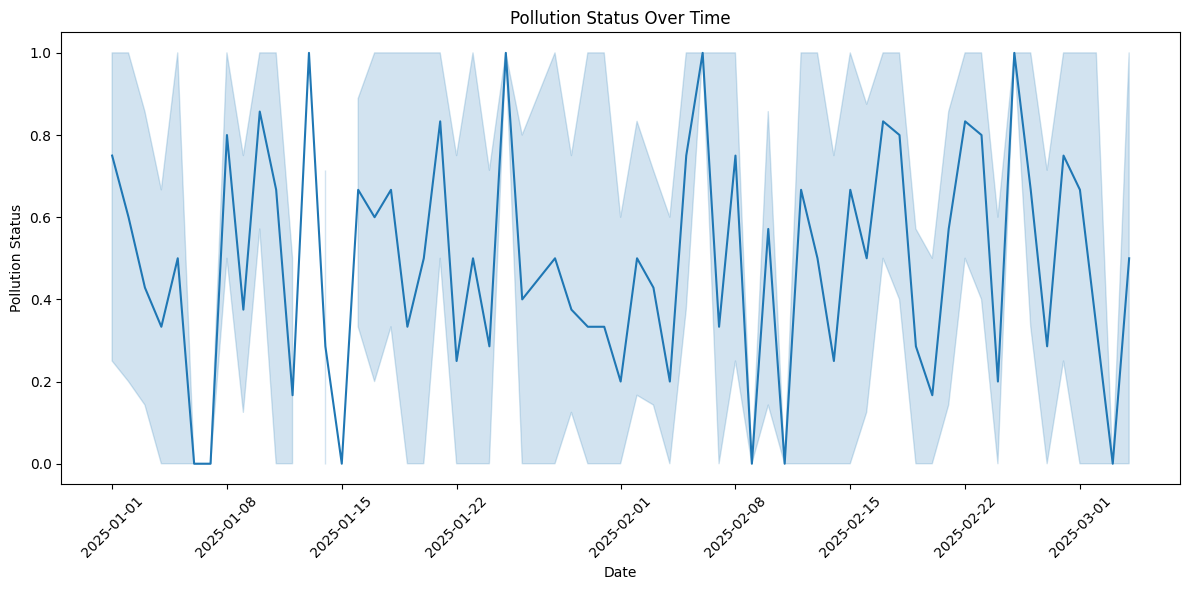

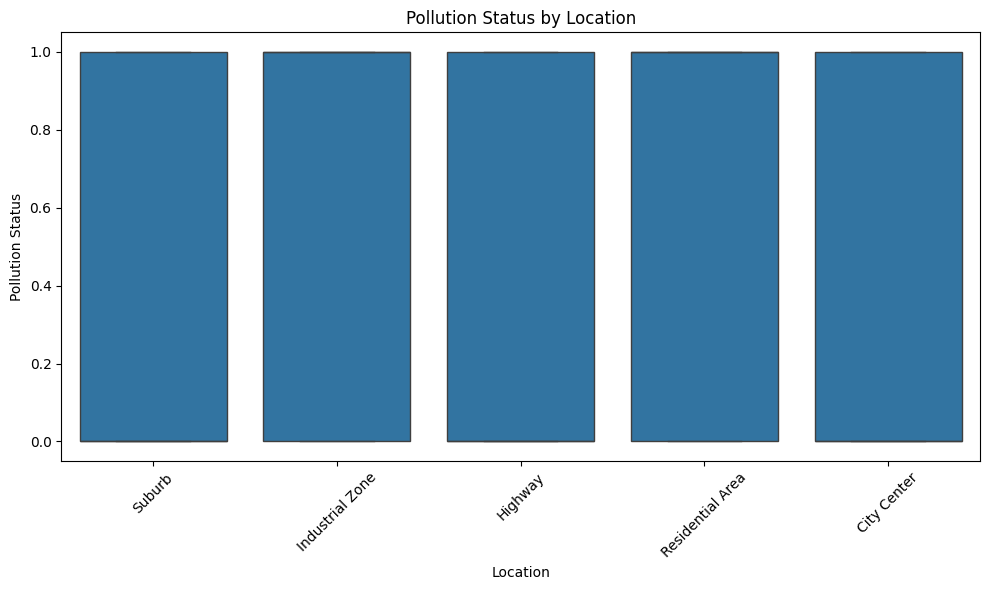

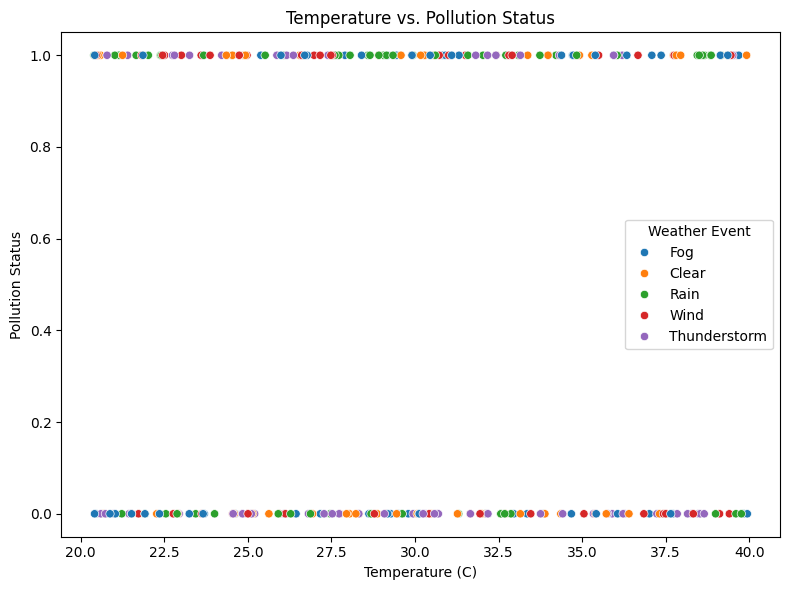

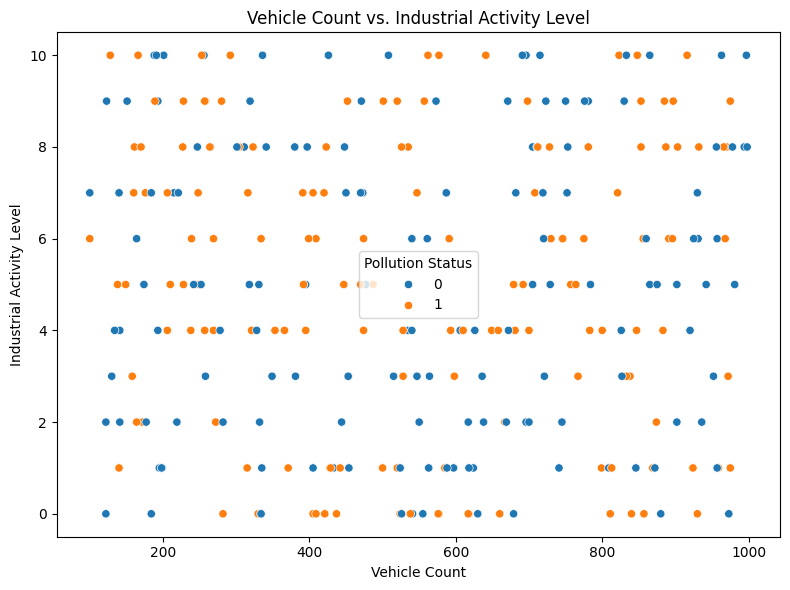

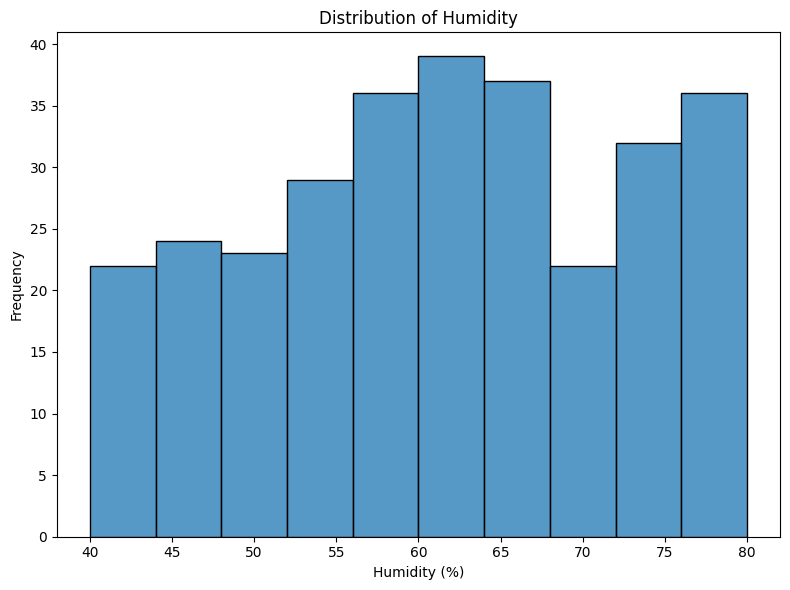

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming dummy_polusi_df is your DataFrame

# 1. Time Series Plot for Pollution Status over Time
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Pollution Status', data=dummy_polusi_df)
plt.title('Pollution Status Over Time')
plt.xlabel('Date')
plt.ylabel('Pollution Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Box Plot for Pollution Status by Location
plt.figure(figsize=(10, 6))
sns.boxplot(x='Location', y='Pollution Status', data=dummy_polusi_df)
plt.title('Pollution Status by Location')
plt.xlabel('Location')
plt.ylabel('Pollution Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Scatter Plot for Temperature vs. Pollution Status
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Temperature (C)', y='Pollution Status', data=dummy_polusi_df, hue='Weather Event')
plt.title('Temperature vs. Pollution Status')
plt.xlabel('Temperature (C)')
plt.ylabel('Pollution Status')
plt.tight_layout()
plt.show()

# 4. Scatter Plot for Vehicle Count vs. Industrial Activity Level
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Vehicle Count', y='Industrial Activity Level', data=dummy_polusi_df, hue='Pollution Status')
plt.title('Vehicle Count vs. Industrial Activity Level')
plt.xlabel('Vehicle Count')
plt.ylabel('Industrial Activity Level')
plt.tight_layout()
plt.show()

# 5. Histogram for Humidity
plt.figure(figsize=(8, 6))
sns.histplot(dummy_polusi_df['Humidity (%)'], bins=10)
plt.title('Distribution of Humidity')
plt.xlabel('Humidity (%)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Langkah 3: Preprocessing Data
Kita akan melakukan encoding pada kolom kategori, seperti 'Pollution Status' dan 'Weather Event'.

In [5]:

# Encoding categorical variables (Pollution Status and Weather Event)
encoder = LabelEncoder()
dummy_polusi_df['Weather Event'] = encoder.fit_transform(dummy_polusi_df['Weather Event'])

# Splitting the data into features and target variable
X = dummy_polusi_df.drop(columns=["Pollution Status", "Date", "Location"])
y = dummy_polusi_df["Pollution Status"]


## Langkah 4: Normalisasi Data
Kita akan melakukan normalisasi pada data fitur untuk memastikan nilai-nilai berada dalam rentang yang seragam.

In [6]:

# Normalizing the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


## Langkah 5: Membagi Data Train dan Test
Kita akan membagi dataset menjadi data pelatihan (train) dan data pengujian (test).

In [7]:

# Splitting the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


## Langkah 6: Melatih Model
Sekarang kita akan membangun dan melatih model **K-Nearest Neighbors (KNN)** untuk memprediksi status polusi udara.

In [8]:

# Building the K-Nearest Neighbors model
knn_model_polusi = KNeighborsClassifier(n_neighbors=5)

# Training the model
knn_model_polusi.fit(X_train, y_train)


KNeighborsClassifier()

## Langkah 7: Evaluasi Model
Setelah model dilatih, kita akan mengevaluasi kinerjanya dengan menggunakan data uji.

In [9]:

# Making predictions on the test set
y_pred_polusi_knn = knn_model_polusi.predict(X_test)

# Evaluating the model
print("Accuracy:", accuracy_score(y_test, y_pred_polusi_knn))
print(classification_report(y_test, y_pred_polusi_knn))


Accuracy: 0.5166666666666667
              precision    recall  f1-score   support

           0       0.57      0.59      0.58        34
           1       0.44      0.42      0.43        26

    accuracy                           0.52        60
   macro avg       0.51      0.51      0.51        60
weighted avg       0.51      0.52      0.52        60



## Langkah 8: Prediksi
Kita akan menggunakan model untuk melakukan prediksi pada data baru.

In [10]:

# Example prediction (predicting on the first row of X_test)
example_prediction_polusi_knn = knn_model_polusi.predict(X_test[:1])
print("Predicted Pollution Status:", example_prediction_polusi_knn)


Predicted Pollution Status: [0]
